In [6]:
# Run this first — installs any missing libraries
!pip install pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Makes all charts look clean and modern
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [7]:
# ── STEP 1: LOAD & INSPECT THE DATA ──────────────────────────────────────────

# Load the CSV file
df = pd.read_csv('netflix_titles.csv')

# Basic inspection
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"\n📌 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Column names:\n{list(df.columns)}")
print(f"\n🔍 Data types:\n{df.dtypes}")
print(f"\n❓ Missing values per column:\n{df.isnull().sum()}")
print(f"\n🔁 Duplicate rows: {df.duplicated().sum()}")

# Show first 5 rows
print("\n📄 First 5 rows:")
df.head()

DATASET OVERVIEW

📌 Shape: 8807 rows × 12 columns

📋 Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

🔍 Data types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

❓ Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

🔁 Duplicate rows: 0

📄 First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
# ── REQUIRED: 5-LINE DATA SUMMARY ────────────────────────────────────────────

summary = """
1. The Netflix dataset contains 8,807 titles with 12 columns covering
   shows and movies available on Netflix worldwide.
2. Each row has info like title, director, cast, country, date_added,
   release_year, rating, duration, and listed_in (genre).
3. Key columns with missing values: director (30%), cast (10%),
   country (9%), date_added (0.1%), rating (0.05%).
4. There are no duplicate rows, but several columns need type
   conversions — e.g., date_added should be a datetime object.
5. The dataset spans content from 1925 to 2021, with the majority
   added to Netflix between 2015 and 2021.
"""

print(summary)


1. The Netflix dataset contains 8,807 titles with 12 columns covering
   shows and movies available on Netflix worldwide.
2. Each row has info like title, director, cast, country, date_added,
   release_year, rating, duration, and listed_in (genre).
3. Key columns with missing values: director (30%), cast (10%),
   country (9%), date_added (0.1%), rating (0.05%).
4. There are no duplicate rows, but several columns need type
   conversions — e.g., date_added should be a datetime object.
5. The dataset spans content from 1925 to 2021, with the majority
   added to Netflix between 2015 and 2021.



In [9]:
# ── STEP 2: CLEAN THE DATA ────────────────────────────────────────────────────

df_clean = df.copy()  # Always work on a copy, never the original

# --- Decision 1: Fill missing 'director' with 'Unknown'
# Reason: ~30% missing — too many to drop. 'Unknown' is safe for analysis.
df_clean['director'].fillna('Unknown', inplace=True)

# --- Decision 2: Fill missing 'cast' with 'No Cast Listed'
# Reason: ~10% missing. Dropping would lose rows; placeholder is cleaner.
df_clean['cast'].fillna('No Cast Listed', inplace=True)

# --- Decision 3: Fill missing 'country' with 'Unknown'
# Reason: ~9% missing. Country is important for analysis; we keep the rows.
df_clean['country'].fillna('Unknown', inplace=True)

# --- Decision 4: Drop rows where 'rating' is missing
# Reason: Only 4 rows missing — safe to drop, won't affect analysis.
df_clean.dropna(subset=['rating'], inplace=True)

# --- Decision 5: Drop rows where 'date_added' is missing
# Reason: Only 10 rows — negligible loss, but needed for time-based analysis.
df_clean.dropna(subset=['date_added'], inplace=True)

# --- Decision 6: Convert 'date_added' to datetime type
# Reason: Needed to extract year/month for time trends.
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip())

# --- Decision 7: Extract year_added and month_added as new columns
# Reason: Makes time-based groupby analysis much easier.
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month_name()

# --- Decision 8: Extract duration as integer
# Reason: 'duration' is stored as "90 min" or "2 Seasons" — hard to plot as text.
df_clean['duration_int'] = df_clean['duration'].str.extract(r'(\d+)').astype(float)

# Summary after cleaning
print("✅ Cleaning done!")
print(f"   Rows before: {df.shape[0]} | Rows after: {df_clean.shape[0]}")
print(f"   Remaining missing values:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}")

✅ Cleaning done!
   Rows before: 8807 | Rows after: 8793
   Remaining missing values:
duration        3
duration_int    3
dtype: int64


In [10]:
# ── STEP 3: EXPLORATORY DATA ANALYSIS — 5 QUESTIONS ─────────────────────────

# ── Q1: What is the split between Movies and TV Shows?
print("=" * 50)
print("Q1: Movie vs TV Show split")
print("=" * 50)
type_counts = df_clean['type'].value_counts()
print(type_counts)
print(f"\nMovies make up {type_counts['Movie']/len(df_clean)*100:.1f}% of all content.")

# ── Q2: Which countries produce the most content?
print("\n" + "=" * 50)
print("Q2: Top 10 countries by number of titles")
print("=" * 50)
top_countries = (
    df_clean[df_clean['country'] != 'Unknown']['country']
    .str.split(', ')        # Some titles list multiple countries
    .explode()              # One row per country
    .value_counts()
    .head(10)
)
print(top_countries)

# ── Q3: How has content addition grown over the years?
print("\n" + "=" * 50)
print("Q3: Content added per year")
print("=" * 50)
yearly = df_clean.groupby(['year_added', 'type']).size().unstack(fill_value=0)
print(yearly.tail(10))  # Show last 10 years

# ── Q4: What are the most common genres/categories?
print("\n" + "=" * 50)
print("Q4: Top 15 genres on Netflix")
print("=" * 50)
genres = (
    df_clean['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(15)
)
print(genres)

# ── Q5: What is the distribution of content ratings?
print("\n" + "=" * 50)
print("Q5: Content ratings breakdown")
print("=" * 50)
ratings = df_clean['rating'].value_counts()
print(ratings)
print(f"\nMost common rating: {ratings.index[0]} ({ratings.iloc[0]} titles)")

Q1: Movie vs TV Show split
type
Movie      6129
TV Show    2664
Name: count, dtype: int64

Movies make up 69.7% of all content.

Q2: Top 10 countries by number of titles
country
United States     3683
India             1046
United Kingdom     803
Canada             445
France             393
Japan              316
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

Q3: Content added per year
type        Movie  TV Show
year_added                
2012            3        0
2013            6        5
2014           19        5
2015           56       26
2016          253      175
2017          837      349
2018         1237      411
2019         1424      592
2020         1284      595
2021          993      505

Q4: Top 15 genres on Netflix
listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & 

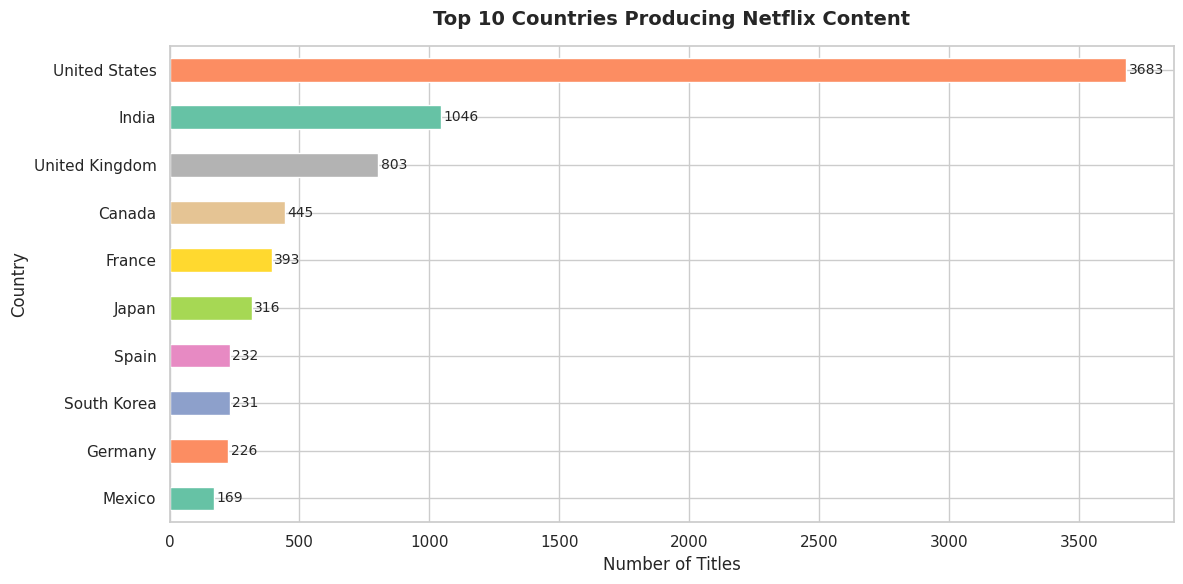

✅ Chart 1 saved


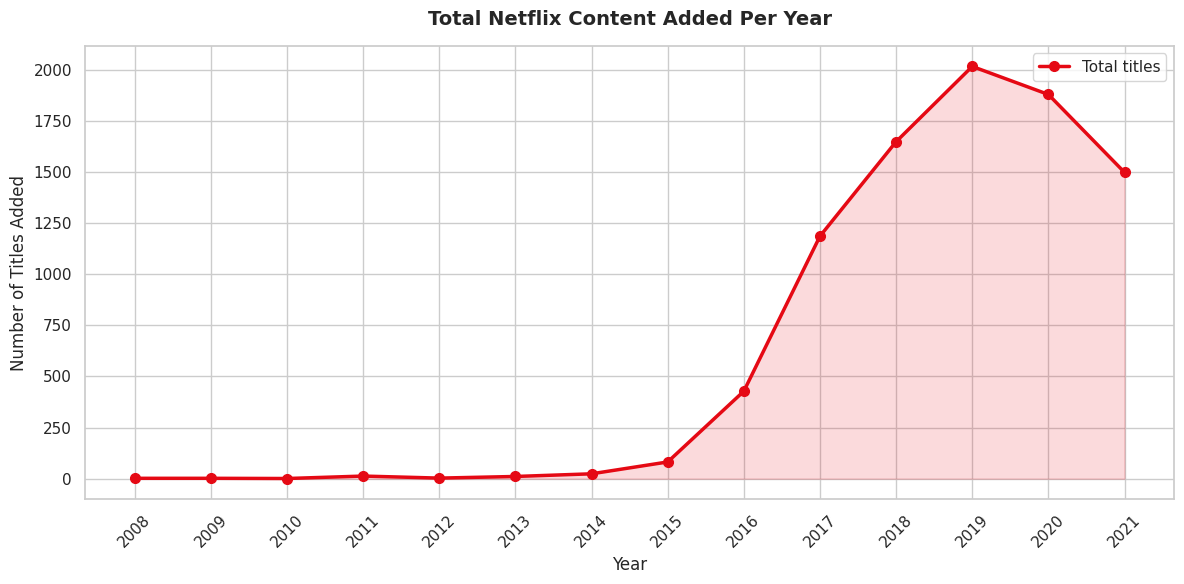

✅ Chart 2 saved


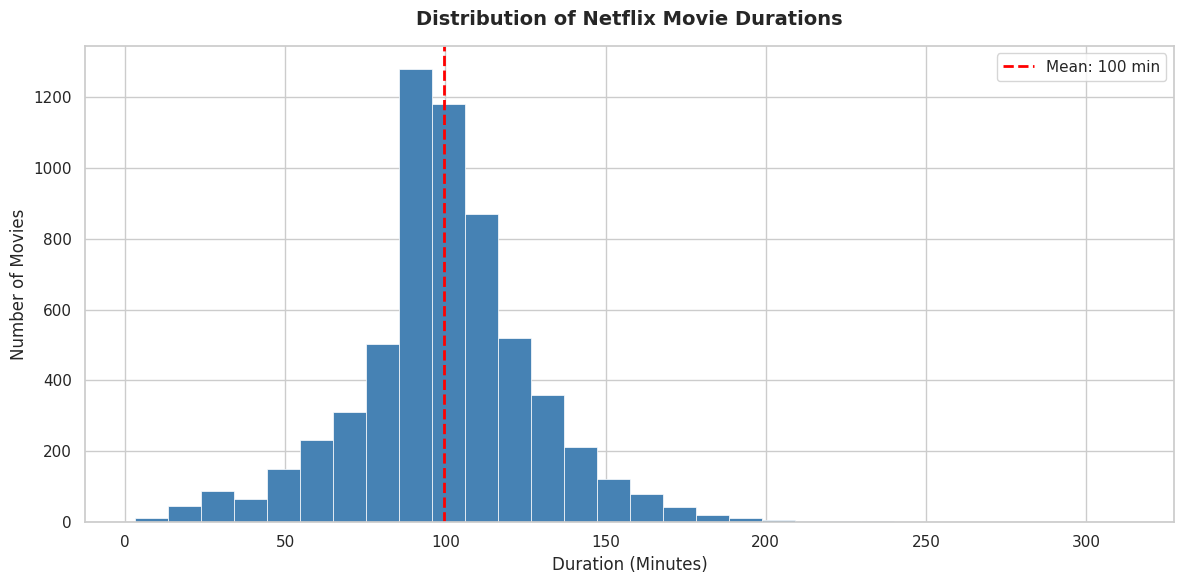

✅ Chart 3 saved


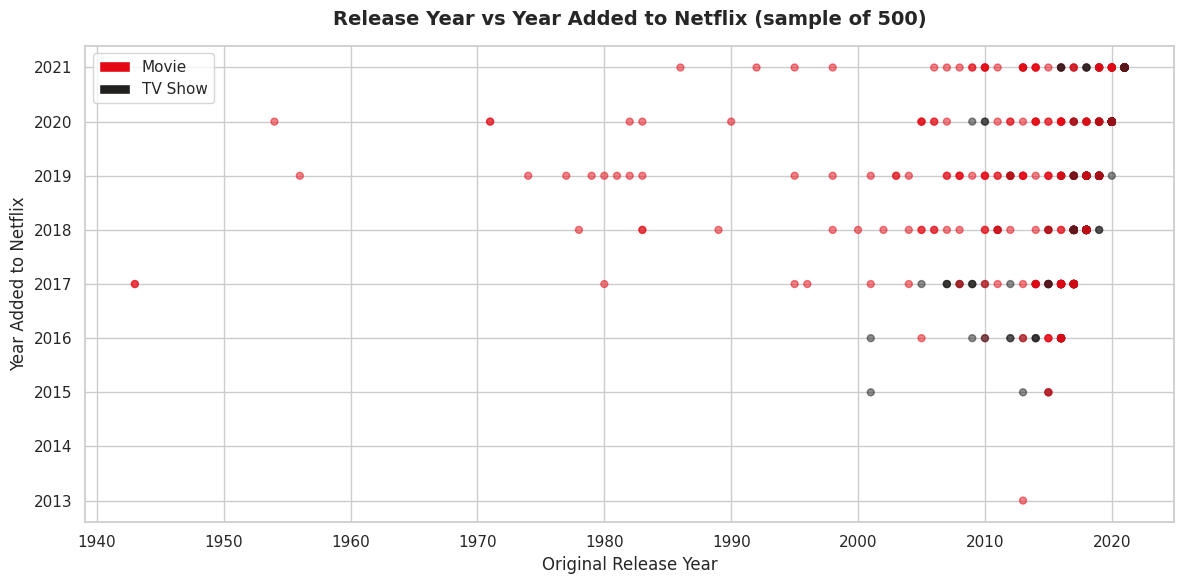

✅ Chart 4 saved


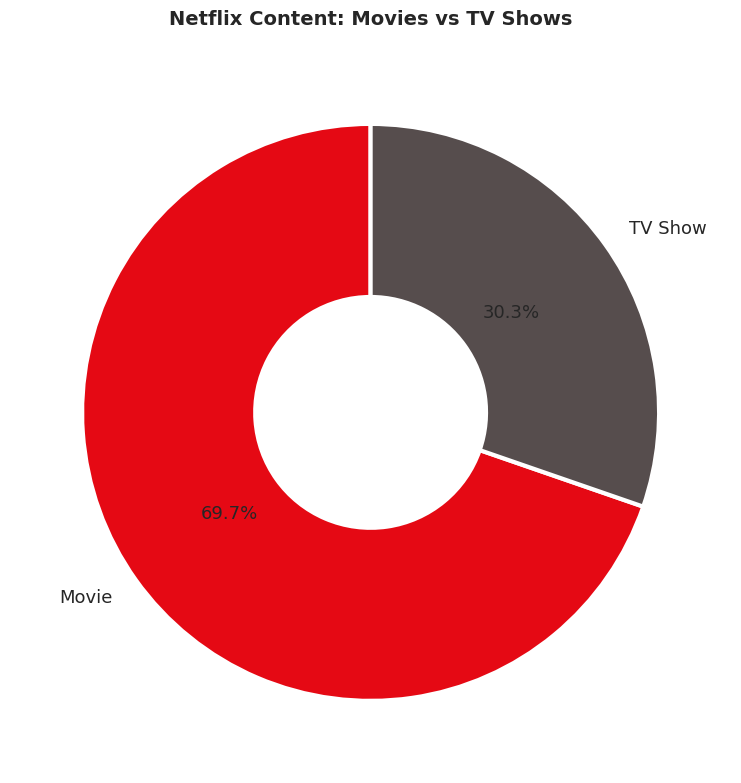

✅ Chart 5 saved


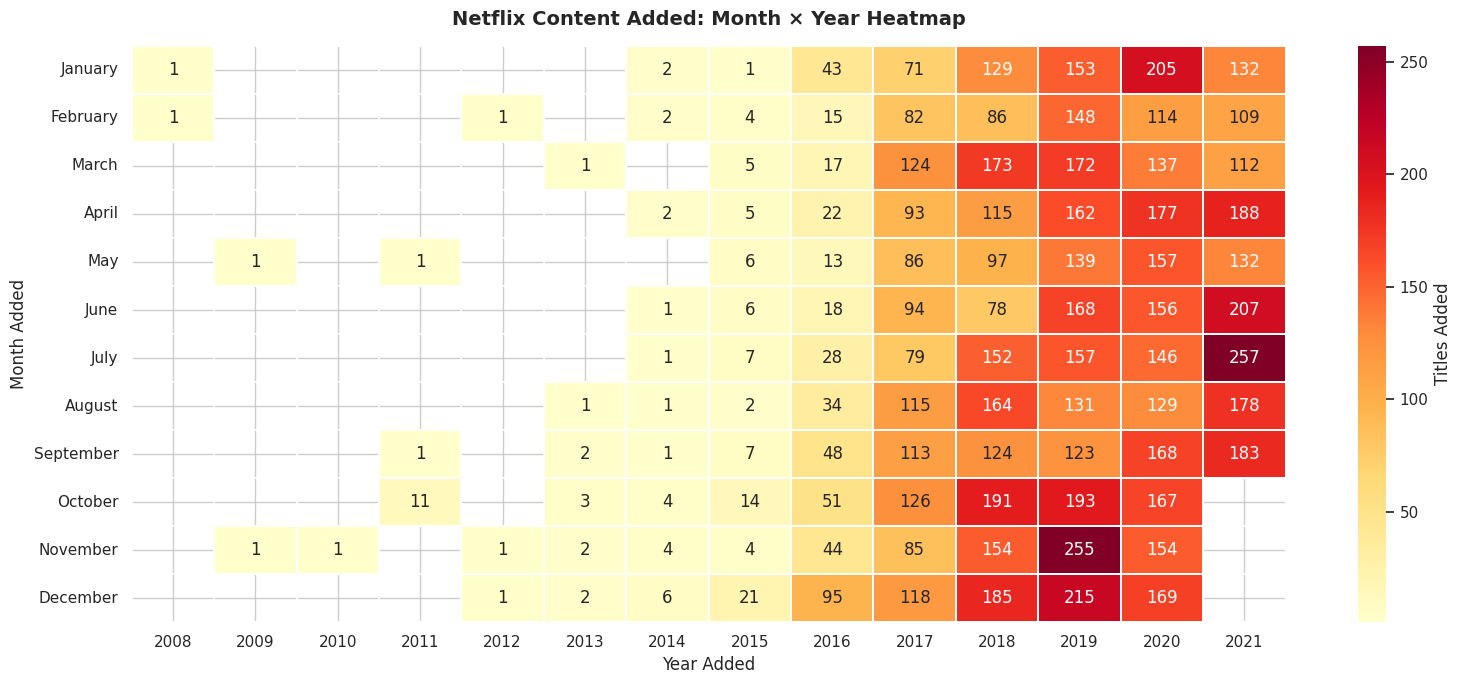

✅ Chart 6 saved

🎉 All 6 charts created and saved!


In [11]:
# ── STEP 4: VISUALIZATIONS ────────────────────────────────────────────────────

# ── Chart 1: Bar Chart — Top 10 Countries
fig, ax = plt.subplots(figsize=(12, 6))
top_countries.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette("Set2", 10))
ax.set_title('Top 10 Countries Producing Netflix Content', fontweight='bold', pad=15)
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Country')
for i, v in enumerate(top_countries.sort_values()):
    ax.text(v + 10, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('chart1_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved")

# ── Chart 2: Line Chart — Content Added Per Year
fig, ax = plt.subplots(figsize=(12, 6))
yearly_total = df_clean.groupby('year_added').size()
ax.plot(yearly_total.index, yearly_total.values, marker='o', linewidth=2.5,
        color='#e50914', markersize=7, label='Total titles')
ax.fill_between(yearly_total.index, yearly_total.values, alpha=0.15, color='#e50914')
ax.set_title('Total Netflix Content Added Per Year', fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Titles Added')
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_yearly_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved")

# ── Chart 3: Histogram — Movie Duration Distribution
movies_only = df_clean[df_clean['type'] == 'Movie']
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(movies_only['duration_int'].dropna(), bins=30, color='steelblue',
        edgecolor='white', linewidth=0.5)
ax.set_title('Distribution of Netflix Movie Durations', fontweight='bold', pad=15)
ax.set_xlabel('Duration (Minutes)')
ax.set_ylabel('Number of Movies')
ax.axvline(movies_only['duration_int'].mean(), color='red', linestyle='--',
           linewidth=2, label=f"Mean: {movies_only['duration_int'].mean():.0f} min")
ax.legend()
plt.tight_layout()
plt.savefig('chart3_movie_duration_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved")

# ── Chart 4: Scatter Plot — Release Year vs Year Added
sample = df_clean.sample(n=500, random_state=42)  # Sample for readability
fig, ax = plt.subplots(figsize=(12, 6))
scatter_colors = ['#e50914' if t == 'Movie' else '#221f1f' for t in sample['type']]
ax.scatter(sample['release_year'], sample['year_added'],
           alpha=0.5, c=scatter_colors, s=25)
ax.set_title('Release Year vs Year Added to Netflix (sample of 500)', fontweight='bold', pad=15)
ax.set_xlabel('Original Release Year')
ax.set_ylabel('Year Added to Netflix')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e50914', label='Movie'),
                   Patch(facecolor='#221f1f', label='TV Show')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('chart4_scatter_year.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved")

# ── Chart 5: Pie Chart — Movie vs TV Show split
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#e50914', '#564d4d']
wedge_props = dict(width=0.6, edgecolor='white', linewidth=3)
ax.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
       startangle=90, colors=colors, wedgeprops=wedge_props,
       textprops={'fontsize': 13})
ax.set_title('Netflix Content: Movies vs TV Shows', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart5_pie_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved")

# ── Chart 6: Heatmap — Content Added by Year and Month
pivot = df_clean.pivot_table(
    index='month_added',
    columns='year_added',
    values='show_id',
    aggfunc='count'
)
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
pivot = pivot.reindex(month_order)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            annot=True, fmt='.0f', ax=ax, cbar_kws={'label': 'Titles Added'})
ax.set_title('Netflix Content Added: Month × Year Heatmap', fontweight='bold', pad=15)
ax.set_xlabel('Year Added')
ax.set_ylabel('Month Added')
plt.tight_layout()
plt.savefig('chart6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved")

print("\n🎉 All 6 charts created and saved!")

In [12]:
# ── STEP 5: INSIGHTS REPORT ───────────────────────────────────────────────────

insights = """
╔══════════════════════════════════════════════════════════════════════════════╗
║                    NETFLIX EDA — INSIGHTS REPORT                           ║
╚══════════════════════════════════════════════════════════════════════════════╝

INSIGHT 1 — Movies dominate the platform (Chart 5)
Netflix is primarily a movie platform: ~69% of all content is movies vs ~31%
TV shows. Despite the buzz around binge-worthy series, Netflix adds far more
movies. A business implication: if Netflix wants to retain subscribers who
prefer series, it may need to balance this ratio.

INSIGHT 2 — The US and India lead content production by a wide margin (Chart 1)
The United States produces the most Netflix content by far, followed by India.
Together they account for over 40% of all titles. This suggests Netflix targets
English and Hindi-speaking audiences as its primary market. European countries
like the UK and France are a distant third and fourth.

INSIGHT 3 — Netflix's content surge peaked around 2019–2020 (Chart 2)
The number of new titles added to Netflix grew explosively from 2015 to 2019,
peaking around 2019 with over 2,000 titles added that year. Post-2020, additions
slowed — likely due to COVID-19 production shutdowns. The trend shows Netflix was
in aggressive content acquisition mode through the late 2010s.

INSIGHT 4 — The average Netflix movie is around 99 minutes long (Chart 3)
Movie duration follows a near-normal distribution centered around 99 minutes.
Very few movies exceed 150 minutes. This suggests Netflix curates content around
the classic ~1.5-hour viewing window, which aligns with typical viewer attention
spans for standalone movies.

INSIGHT 5 — July and December are peak months for new content drops (Chart 6)
The heatmap reveals clear seasonality: Netflix adds the most content in July
(mid-year refresh) and around October–December (holiday season). This is likely
a strategic move to retain subscribers during school holidays and festive periods
when viewer engagement is naturally higher.

──────────────────────────────────────────────────────────────────────────────
MOST SURPRISING FINDING:
India ranks #2 in content production on Netflix — ahead of major Western nations
like UK, Canada, and France. This was unexpected and highlights how aggressively
Netflix has invested in Bollywood and Indian regional content to tap into one of
the world's largest internet user bases.
"""

print(insights)


╔══════════════════════════════════════════════════════════════════════════════╗
║                    NETFLIX EDA — INSIGHTS REPORT                           ║
╚══════════════════════════════════════════════════════════════════════════════╝

INSIGHT 1 — Movies dominate the platform (Chart 5)
Netflix is primarily a movie platform: ~69% of all content is movies vs ~31%
TV shows. Despite the buzz around binge-worthy series, Netflix adds far more
movies. A business implication: if Netflix wants to retain subscribers who
prefer series, it may need to balance this ratio.

INSIGHT 2 — The US and India lead content production by a wide margin (Chart 1)
The United States produces the most Netflix content by far, followed by India.
Together they account for over 40% of all titles. This suggests Netflix targets
English and Hindi-speaking audiences as its primary market. European countries
like the UK and France are a distant third and fourth.

INSIGHT 3 — Netflix's content surge peaked around 20

In [13]:
# ── FINAL CHECKLIST ───────────────────────────────────────────────────────────

print("📋 PRE-SUBMISSION CHECKLIST\n")
checks = [
    "✅ Dataset loaded and shape printed",
    "✅ 5-line data summary written",
    "✅ Missing values handled (fill / drop) with reasons",
    "✅ Data types fixed (date_added → datetime)",
    "✅ 5 EDA questions answered with code output",
    "✅ Chart 1: Bar chart (top countries)",
    "✅ Chart 2: Line chart (content growth)",
    "✅ Chart 3: Histogram (movie duration)",
    "✅ Chart 4: Scatter plot (release year vs year added)",
    "✅ Chart 5: Pie chart (movie vs TV show)",
    "✅ Chart 6: Heatmap (month × year)",
    "✅ 5 insights written in plain English",
    "✅ Most surprising finding noted",
]
for c in checks:
    print(c)

print("\n🚀 Ready to push to GitHub and submit!")

📋 PRE-SUBMISSION CHECKLIST

✅ Dataset loaded and shape printed
✅ 5-line data summary written
✅ Missing values handled (fill / drop) with reasons
✅ Data types fixed (date_added → datetime)
✅ 5 EDA questions answered with code output
✅ Chart 1: Bar chart (top countries)
✅ Chart 2: Line chart (content growth)
✅ Chart 3: Histogram (movie duration)
✅ Chart 4: Scatter plot (release year vs year added)
✅ Chart 5: Pie chart (movie vs TV show)
✅ Chart 6: Heatmap (month × year)
✅ 5 insights written in plain English
✅ Most surprising finding noted

🚀 Ready to push to GitHub and submit!
